In [21]:
from jax.scipy.stats import norm, poisson
import jax.numpy as jnp
import jax
import matplotlib.pyplot as plt

from algorithms.smc import particle_filter
from time import perf_counter
import seaborn as sb

from utilities.helpers import (
    autocorrelation,
    auto_window,
    autocorr_new,
    effective_sample_size,
)

is_accelerator = jax.devices()[0].platform != "cpu"
print(f"Using Accelerator: {is_accelerator}")

Using Accelerator: True


In [22]:
def model(x0, theta, key, t_range):
    delta_t = t_range[1] - t_range[0]

    exp_theta = jnp.exp(theta)

    gamma, xi, alpha, eta, damping, log_mean, log_std = exp_theta
    log_beta_damping = damping
    log_beta_mean = jnp.log(log_mean)
    log_beta_standard_deviation = log_std

    A = jnp.exp(-log_beta_damping * delta_t)
    M = log_beta_mean * (jnp.exp(-log_beta_damping * delta_t) - 1)
    C = log_beta_standard_deviation * jnp.sqrt(
        1 - jnp.exp(-2 * log_beta_damping * delta_t)
    )

    def tau_step(state, i):
        prev_x, prev_key = state
        S, I, H, R, log_beta = prev_x

        N = S + I + R + H

        update_key, next_key = jax.random.split(prev_key, 2)
        update_keys = jax.random.split(update_key, 6)

        log_beta = A * log_beta - M + C * jax.random.normal(update_keys[0])

        new_S = jax.random.poisson(update_keys[1], xi * R * delta_t)

        new_I = jax.random.poisson(
            update_keys[2], (jnp.exp(log_beta) * S * I) / N * delta_t
        )
        new_IH = jax.random.poisson(update_keys[3], alpha * gamma * I * delta_t)
        new_HR = jax.random.poisson(update_keys[4], eta * H * delta_t)
        new_IR = jax.random.poisson(update_keys[5], alpha * (1 - gamma) * I * delta_t)

        S = jnp.maximum(0.0, S + new_S - new_I)
        I = jnp.maximum(0.0, I + new_I - (new_IH + new_IR))
        H = jnp.maximum(0.0, H + new_IH - new_HR)
        R = jnp.maximum(0.0, R + new_HR + new_IR - new_S)

        return (jnp.array([S, I, H, R, log_beta]), next_key), jnp.array(
            [S, I, H, R, log_beta]
        )

    _, loop_val = jax.lax.scan(
        tau_step,
        init=(x0, key),
        xs=t_range[1:],
    )

    return jnp.concatenate((x0[jnp.newaxis, :], loop_val))

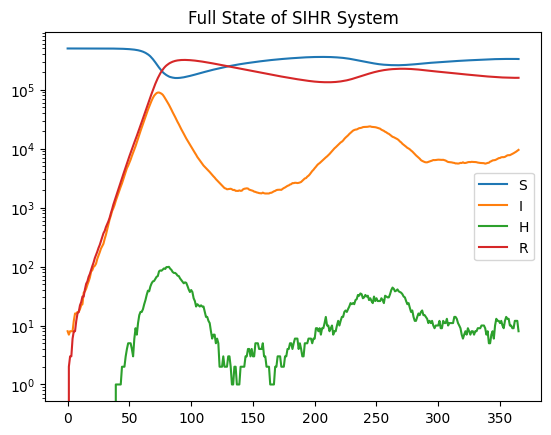

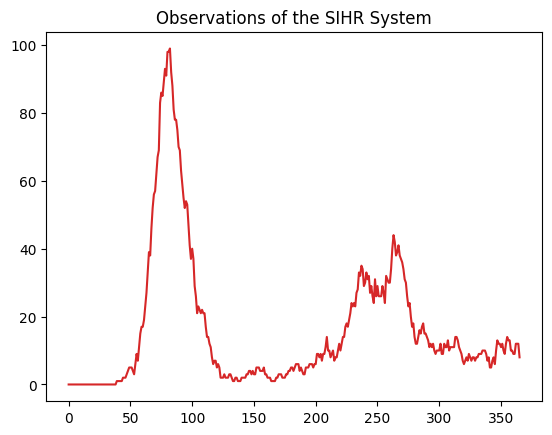

In [23]:
theta = jnp.log(jnp.array([1 / 1000, 1 / 90, 1 / 5, 1 / 7, 1 / 35, 0.35, 0.15]))
delta_t = 1.0
days = 365
rng_key = jax.random.key(5)
t_range = jnp.arange(0, days + delta_t, delta_t)


SIR_init_key, rng_key = jax.random.split(rng_key)
beta_init_key, rng_key = jax.random.split(rng_key)
I_x0 = jax.random.randint(SIR_init_key, minval=0, maxval=100, shape=())

x0 = jnp.full(shape=(4), fill_value=jnp.array([500_000.0, 0.0, 0.0, 0.0]))

x0 = x0.at[0].set(x0[0] - I_x0)
x0 = x0.at[1].set(x0[1] + I_x0)

beta_x0 = jax.random.uniform(beta_init_key, minval=0.1, maxval=0.3)

beta_x0 = beta_x0[..., jnp.newaxis]

x0 = jnp.concatenate((x0, jnp.log(beta_x0)), axis=-1)

run_key, rng_key = jax.random.split(rng_key)
full_state = model(x0, theta, run_key, t_range)

observations = full_state[:, -3]

plt.title('Full State of SIHR System')
plt.yscale('log')
plt.plot(t_range,full_state[:,:-1], label = ['S','I','H','R'])
plt.legend()
plt.show()

plt.title("Observations of the SIHR System")
plt.plot(
    t_range,
    observations.T,
    color="tab:red",
)
plt.show()

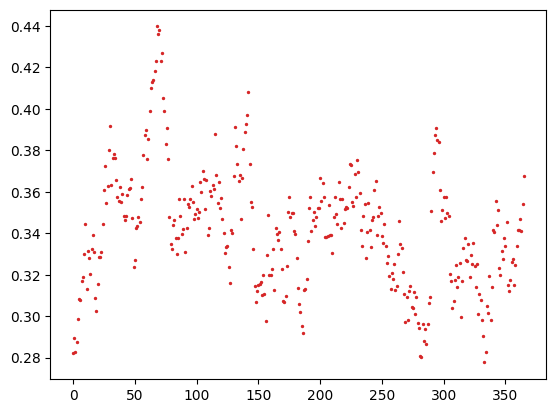

In [24]:
plt.scatter(
        t_range,
        jnp.exp(full_state[:,-1]).T,
        color="tab:red",
        s = 2.0,
        zorder=100
    )

In [25]:
def likelihood(particles, observation, par):
    return jax.scipy.stats.poisson.logpmf(observation, mu=particles[:, 2] + 0.001)

In [26]:
prior_mean = jnp.log(jnp.array([1 / 750, 1 / 50, 1 / 2, 1 / 2, 1 / 15, 0.30, 0.4]))
prior_cov = 0.2 * jnp.eye(len(prior_mean))

def prior(par):
    return jax.scipy.stats.multivariate_normal.logpdf(par,prior_mean,prior_cov)


def f(par, observations, m, key):
    mask = jnp.arange(observations.shape[0]) < m

    num_particles = 100
    key, init_key = jax.random.split(key)
    I_x0 = jax.random.randint(init_key, minval=0, maxval=100, shape=(num_particles,))

    particles = jnp.full(
        shape=(num_particles, 5), fill_value=jnp.array([500_000.0, 0.0, 0.0, 0.0, 0.0])
    )
    beta_x0 = jax.random.uniform(
        beta_init_key, shape=(num_particles,), minval=0.1, maxval=0.5
    )

    particles = particles.at[:, 0].set(particles[:, 0] - I_x0)
    particles = particles.at[:, 1].set(particles[:, 1] + I_x0)

    particles = particles.at[:, -1].set(jnp.log(beta_x0))

    particles, log_weights = particle_filter(
        model,
        observations,
        particles,
        key,
        likelihood,
        par,
        jnp.linspace(0, 1, 2),
    )

    log_means = jax.scipy.special.logsumexp(log_weights, axis=0) - jnp.log(
        num_particles
    )

    return jnp.sum(jnp.where(mask, log_means, 0.0)) + prior(par)

In [27]:
from algorithms.smc import ibis

num_particles = 1000
dim = 7
(
    p_init_key,
    rng_key,
) = jax.random.split(rng_key)
particles = jax.random.multivariate_normal(p_init_key, prior_mean, prior_cov,shape = (num_particles,))

k = 5
ibis_key, key = jax.random.split(rng_key)
particles = ibis(f, observations, k, particles, ibis_key)

Iteration 0 with ESS 999.9998168945312
Iteration 1 with ESS 999.5551147460938
Iteration 2 with ESS 999.00244140625
Iteration 3 with ESS 998.5453491210938
Iteration 4 with ESS 998.0850219726562
Iteration 5 with ESS 997.5376586914062
Iteration 6 with ESS 996.946044921875
Iteration 7 with ESS 996.1821899414062
Iteration 8 with ESS 995.2688598632812
Iteration 9 with ESS 994.2447509765625
Iteration 10 with ESS 992.9361572265625
Iteration 11 with ESS 991.3600463867188
Iteration 12 with ESS 989.3001098632812
Iteration 13 with ESS 987.08740234375
Iteration 14 with ESS 984.5935668945312
Iteration 15 with ESS 981.8506469726562
Iteration 16 with ESS 978.93359375
Iteration 17 with ESS 975.962158203125
Iteration 18 with ESS 972.8356323242188
Iteration 19 with ESS 969.6315307617188
Iteration 20 with ESS 966.2974853515625
Iteration 21 with ESS 962.9296875
Iteration 22 with ESS 959.7874755859375
Iteration 23 with ESS 956.2010498046875
Iteration 24 with ESS 952.8123168945312
Iteration 25 with ESS 949.6

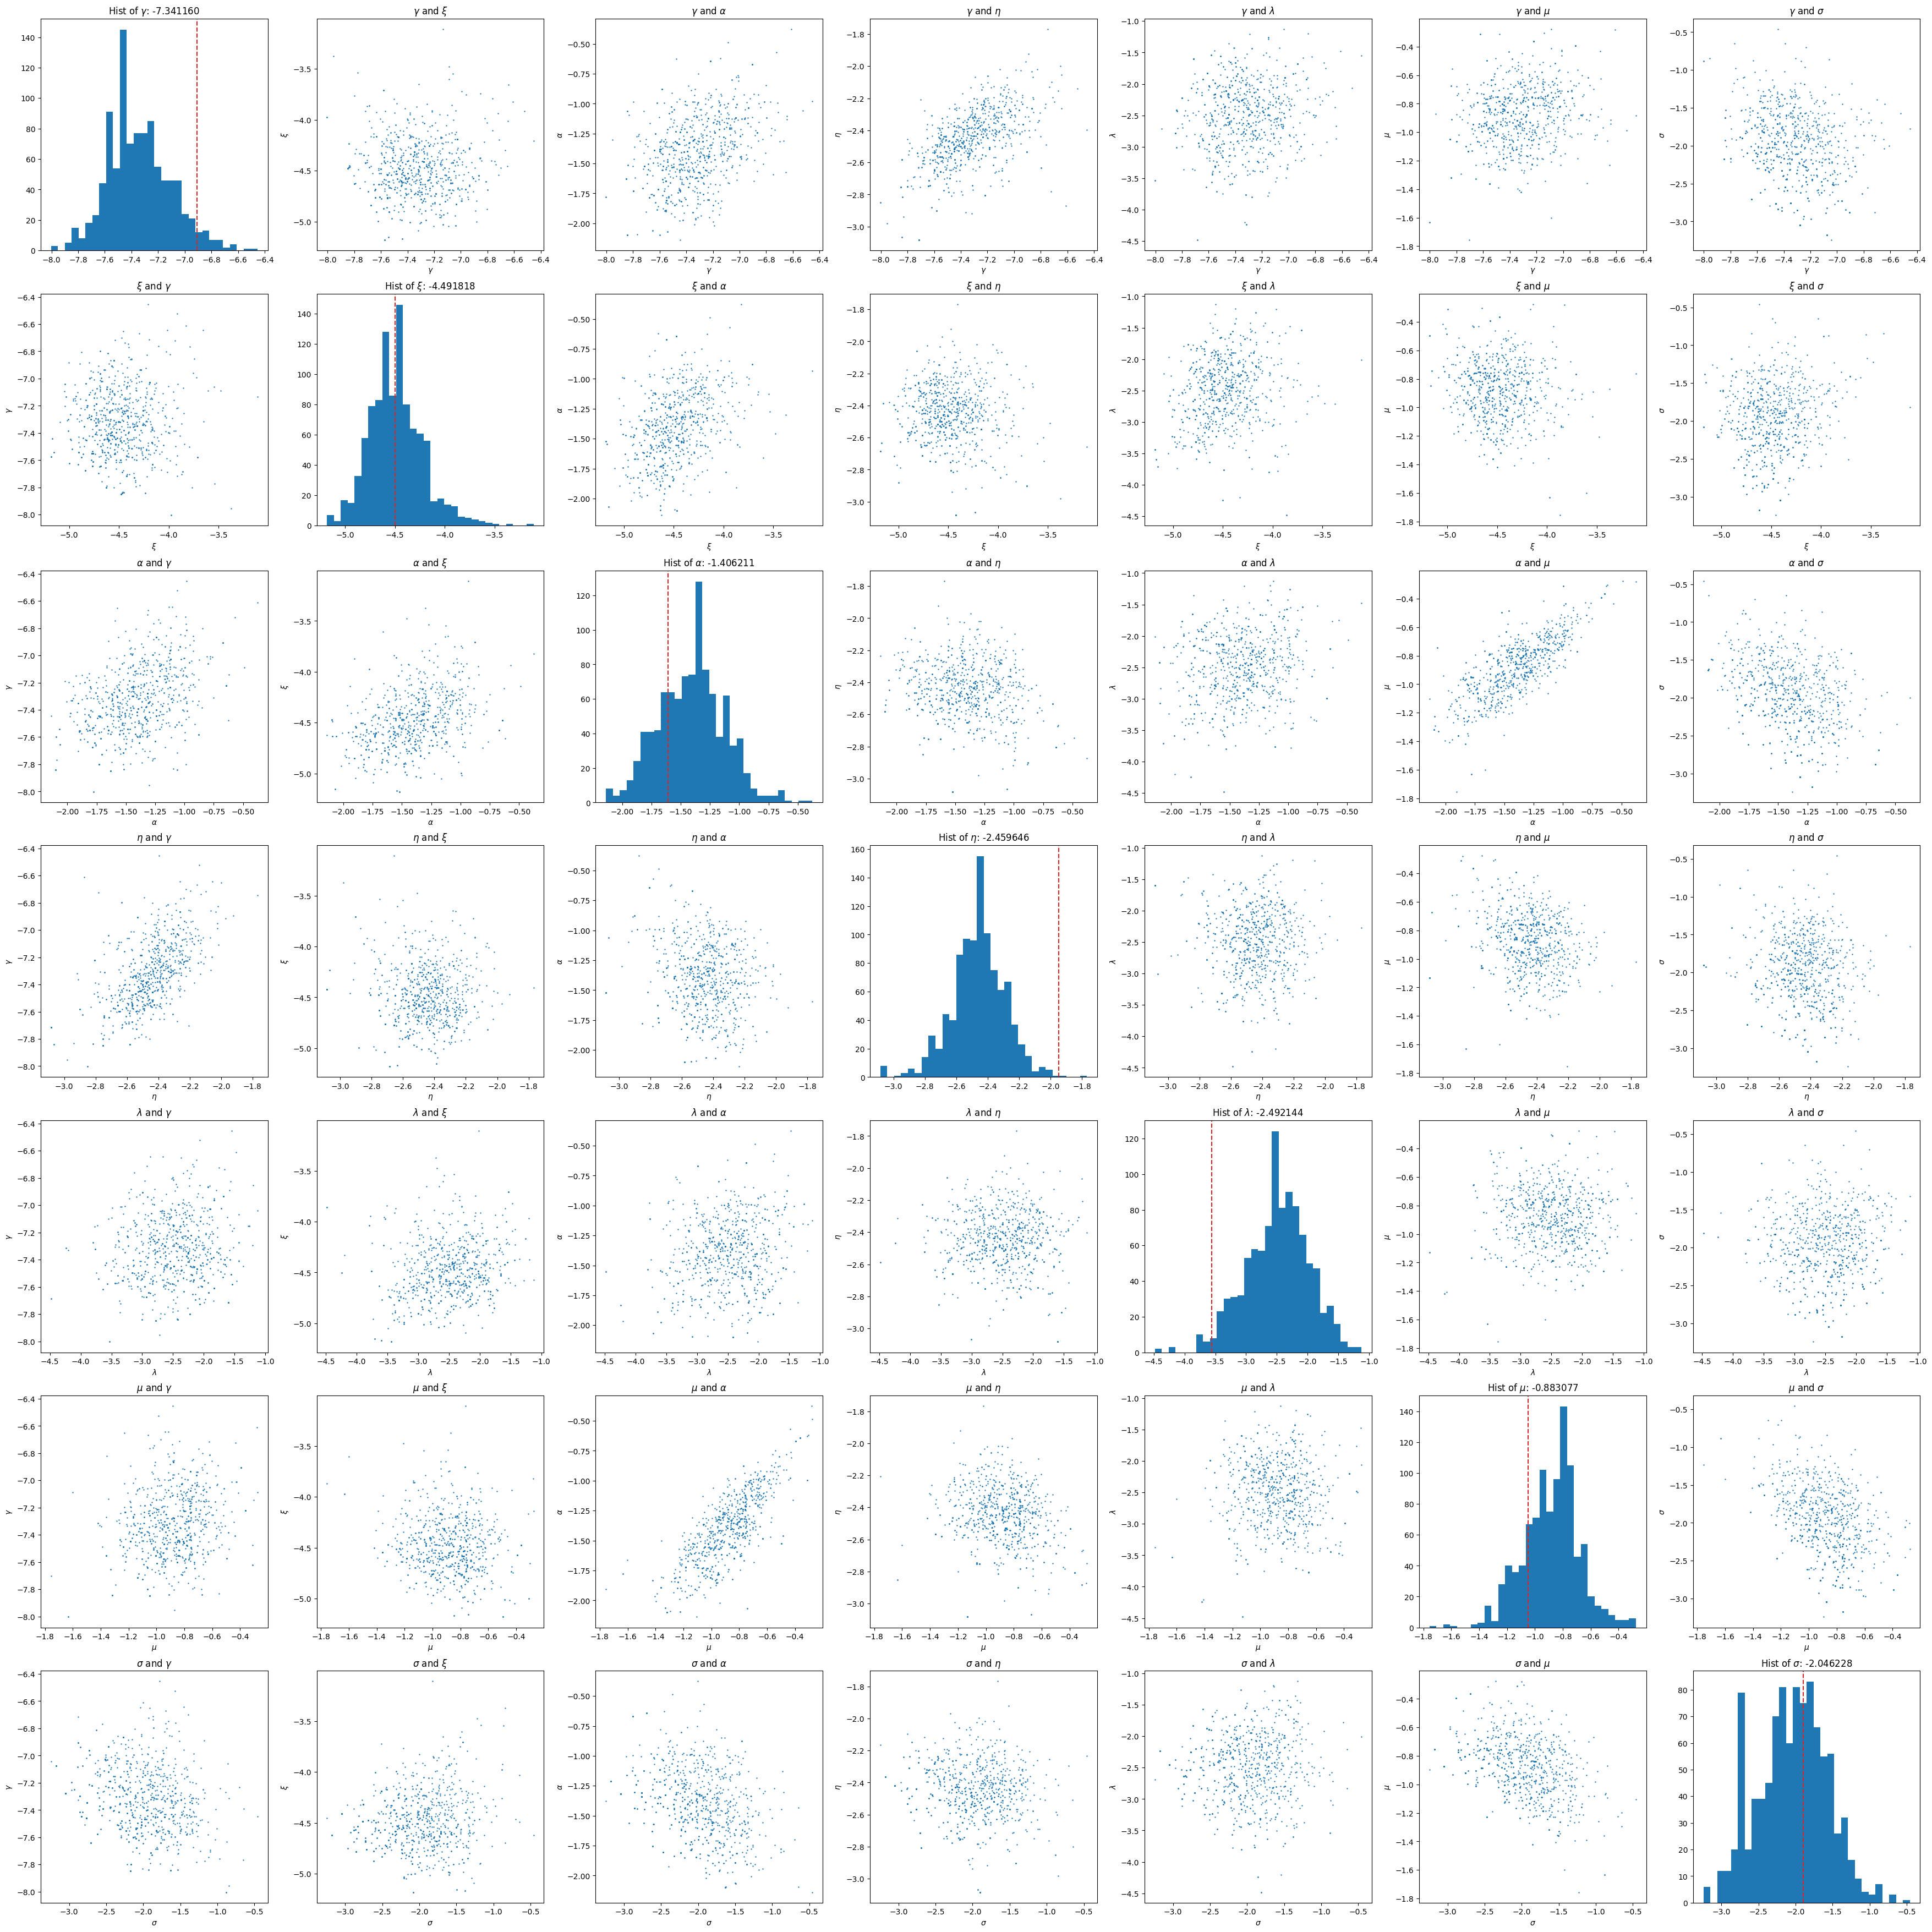

In [28]:
fig, axes = plt.subplots(dim, dim, figsize=(5 * dim, 5 * dim), layout="constrained")

par_names = [
    "$\\gamma$",
    "$\\xi$",
    "$\\alpha$",
    "$\\eta$",
    "$\\lambda$",
    "$\\mu$",
    "$\\sigma$",
]

for par1_index in range(dim):
    for par2_index in range(dim):
        if par1_index != par2_index:
            axes[par1_index, par2_index].set_title(
                f"{par_names[par1_index]} and {par_names[par2_index]}"
            )
            axes[par1_index, par2_index].scatter(
                particles[:, par1_index],
                particles[:, par2_index],
                s=0.5,
            )
            axes[par1_index, par2_index].set_xlabel(f"{par_names[par1_index]}")
            axes[par1_index, par2_index].set_ylabel(f"{par_names[par2_index]}")

        else:
            axes[par1_index, par2_index].hist(particles[:, par1_index], bins=30)
            axes[par1_index, par2_index].set_title(
                f"Hist of {par_names[par1_index]}: {jnp.mean(particles[:, par1_index], axis=0):.6f}"
            )
            axes[par1_index, par2_index].axvline(
                theta[par1_index], color="tab:red", ls="dashed"
            )

plt.show()